In [1]:
import glob

import numpy as np
import xarray as xr
import geopandas as gp
import regionmask
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

## Read AGCD monthly precipitation data

In [2]:
agcd_files = sorted(glob.glob('/g/data/zv2/agcd/v2-0-4/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_*.nc'))

In [3]:
ds = xr.open_mfdataset(agcd_files)
ds = ds.drop_vars(['lat_bnds', 'lon_bnds', 'time_bnds', 'crs'])
ds = ds.sel(lat=slice(-39.5, -33.5))
ds = ds.sel(lon=slice(140, 151))

In [9]:
lat_attrs = ds['lat'].attrs
lon_attrs = ds['lon'].attrs
start_lat = float(ds.lat.values[0])
end_lat = float(ds.lat.values[-1]) + 0.01
ds['lat'] = np.round(np.arange(start_lat, end_lat, 0.05), decimals=2)
ds['lat'].attrs = lat_attrs
start_lon = float(ds.lon.values[0])
end_lon = float(ds.lon.values[-1]) + 0.01
ds['lon'] = np.round(np.arange(start_lon, end_lon, 0.05), decimals=2)
ds['lon'].attrs = lon_attrs

In [10]:
ds = ds.compute()

In [11]:
ds

<xarray.Dataset> Size: 162MB
Dimensions:  (time: 1512, lat: 121, lon: 221)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1900-01-16 ... 2025-12-16
  * lat      (lat) float64 968B -39.5 -39.45 -39.4 -39.35 ... -33.6 -33.55 -33.5
  * lon      (lon) float64 2kB 140.0 140.1 140.1 140.2 ... 150.9 150.9 151.0
Data variables:
    precip   (time, lat, lon) float32 162MB 51.72 51.93 52.1 ... 64.58 69.31
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1900-01-01T00:00:00
    date_created:              2020-08-27T21:49:15.867624
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2026-05-12 23:28:41
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2026, ...
    history:

## Read shapefiles

In [32]:
valid_regions = [
    'victoria',
    'southern_slopes_east_vic',
    'southern_slopes_west_vic',
    'murray_basin_vic',
]

def read_shapefile(region_name):
    assert region_name in valid_regions
    gdf = gp.read_file(f'/g/data/xv83/dbi599/vicwaci/shapefiles/{region_name}.shp')
    region = regionmask.from_geopandas(gdf)

    return region


def plot_frac(frac):
    fig = plt.figure(figsize=[8,4])
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    frac.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues')
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)
    plt.show()


def plot_monthly_clim(spatial_mean):
    monthly_clim = spatial_mean.groupby('time.month').mean()
    monthly_clim.plot()
    plt.ylabel('mm')
    plt.xlabel('month')
    plt.show()
    

def spatial_mean(ds, region_name, overlap_threshold=0.5):
    """Calculate spatial mean"""

    region = read_shapefile(region_name)    
    frac = region.mask_3D_frac_approx(ds).isel(region=0)
    plot_frac(frac)
    weights = np.cos(np.deg2rad(ds['lat']))
    spatial_mean = ds['precip'].weighted(frac * weights).mean(dim=("lat", "lon"))
    spatial_mean = np.round(spatial_mean, decimals=2)
    plot_monthly_clim(spatial_mean)
    
    spatial_mean = spatial_mean.drop_vars(['region', 'abbrevs', 'names'])
    spatial_mean = spatial_mean.to_dataset()
    spatial_mean['time'].attrs = {
        'axis': 'T',
        'standard_name': 'time',
        'long_name' : 'time'
    }
    spatial_mean['precip'].attrs = {
        'units': 'mm',
        'long_name': 'spatial mean monthly precipitation',
    }
    spatial_mean.attrs = {
        'summary': f'total monthly precipitation averaged over the {region_name} region',
        'id': 'Australian Gridded Climate Data (AGCD)',
        'attribution': ds.attrs['attribution'],
    }
    
    region_fname = region_name.replace('_', '-')
    outfile = f'/g/data/xv83/dbi599/vicwaci/agcd_v2-0-4_precip_total_{region_fname}_monthly_1900-2025.nc'
    spatial_mean.to_netcdf(outfile, encoding={'time': {'_FillValue': None}, 'precip': {'_FillValue': None}})
    print(outfile)

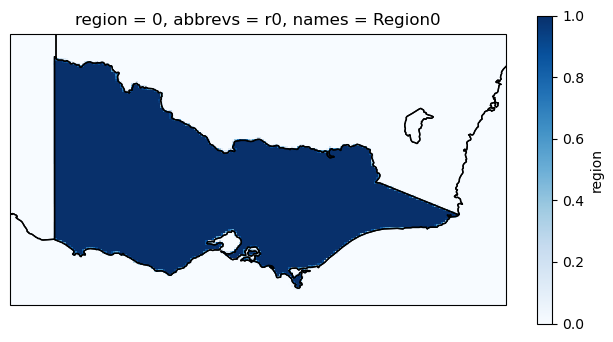

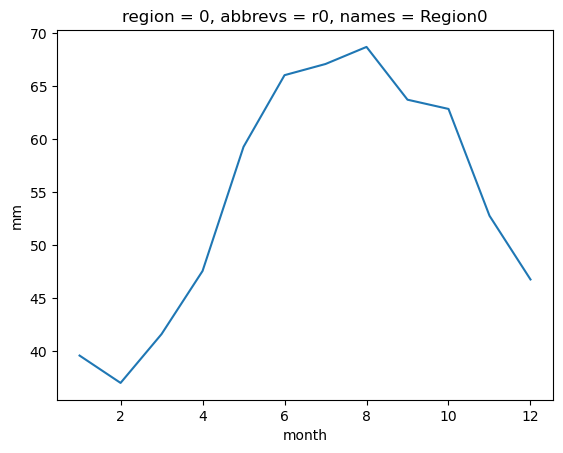

/g/data/xv83/dbi599/vicwaci/agcd_v2-0-4_precip_total_victoria_monthly_1900-2025.nc


In [34]:
spatial_mean(ds, 'victoria')

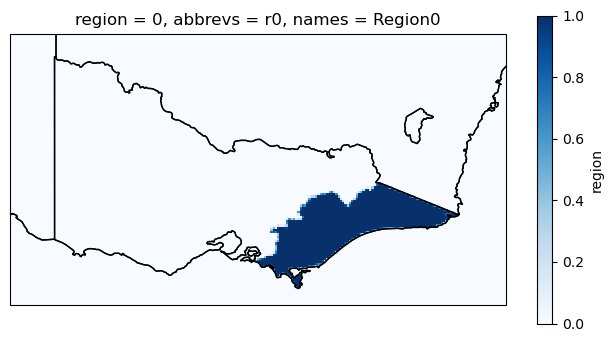

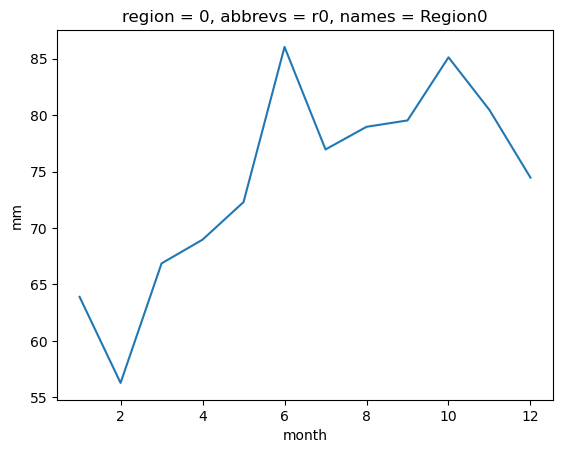

/g/data/xv83/dbi599/vicwaci/agcd_v2-0-4_precip_total_southern-slopes-east-vic_monthly_1900-2025.nc


In [35]:
spatial_mean(ds, 'southern_slopes_east_vic')

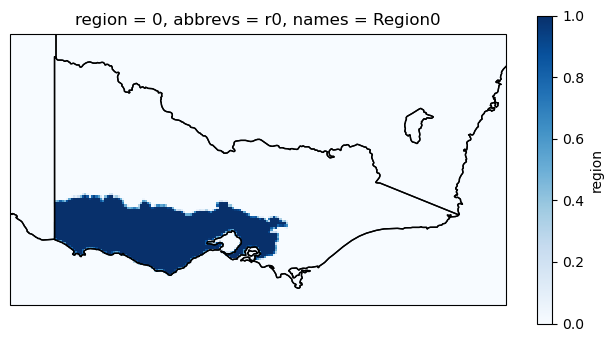

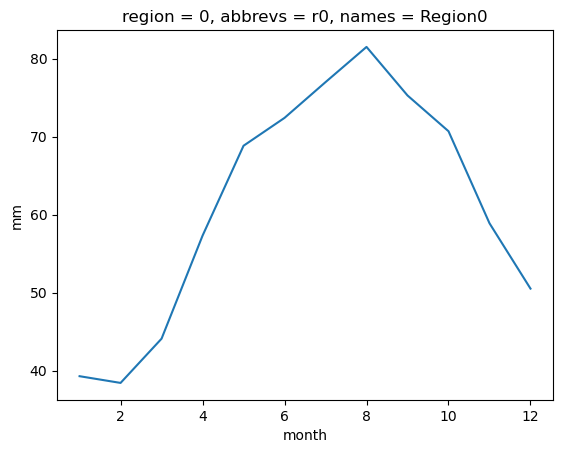

/g/data/xv83/dbi599/vicwaci/agcd_v2-0-4_precip_total_southern-slopes-west-vic_monthly_1900-2025.nc


In [36]:
spatial_mean(ds, 'southern_slopes_west_vic')

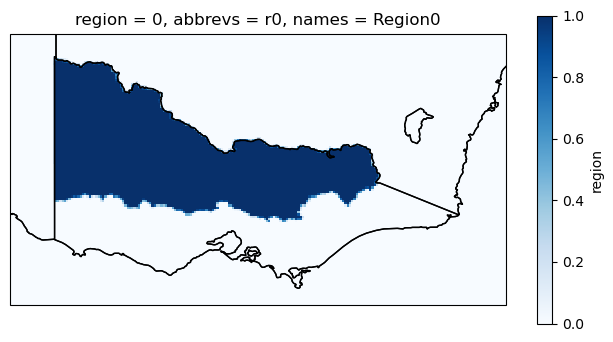

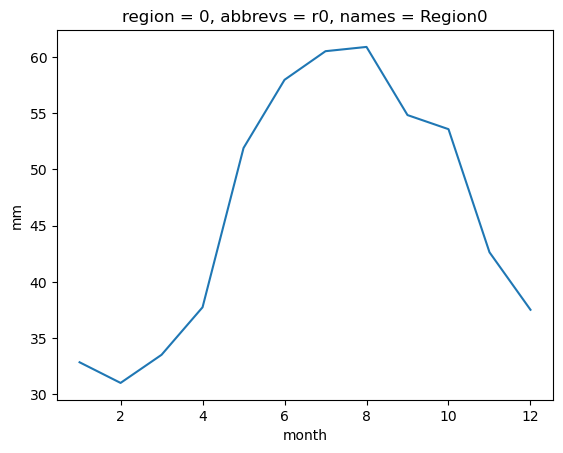

/g/data/xv83/dbi599/vicwaci/agcd_v2-0-4_precip_total_murray-basin-vic_monthly_1900-2025.nc


In [37]:
spatial_mean(ds, 'murray_basin_vic')